In [1]:
!pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [4]:
!ls

archive.zip  sample_data


In [5]:
!unzip archive.zip

Archive:  archive.zip
  inflating: loan_prediction.csv     


In [6]:
!ls

archive.zip  loan_prediction.csv  sample_data


In [7]:
df = pd.read_csv("loan_prediction.csv")

In [8]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
df.shape

(614, 13)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [11]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [12]:
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [13]:
df.fillna(df.mode().iloc[0], inplace=True)

In [14]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [16]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,120.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [8]:
import pandas as pd

In [11]:
!ls

sample_data


In [12]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [13]:
!ls

archive.zip  sample_data


In [14]:
import pandas as pd

df = pd.read_csv("archive.zip")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [15]:
!unzip archive.zip

Archive:  archive.zip
  inflating: loan_prediction.csv     


In [16]:
!ls

archive.zip  loan_prediction.csv  sample_data


In [17]:
import pandas as pd

df = pd.read_csv("loan_prediction.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [18]:
df.shape

(614, 13)

In [19]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [20]:
df.fillna(df.mode().iloc[0], inplace=True)

In [21]:
df.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,120.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [23]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print(X.shape)
print(y.shape)

(614, 12)
(614,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(491, 12)
(123, 12)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
print(y_train.value_counts())

Loan_Status
1    337
0    154
Name: count, dtype: int64


In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

Loan_Status
1    337
0    337
Name: count, dtype: int64


In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

lr_pred = lr.predict(X_test)

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.77      0.61      0.68        38
           1       0.84      0.92      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.76      0.78       123
weighted avg       0.82      0.82      0.81       123



In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

rf_pred = rf.predict(X_test)

In [32]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.77      0.63      0.70        38
           1       0.85      0.92      0.88        85

    accuracy                           0.83       123
   macro avg       0.81      0.77      0.79       123
weighted avg       0.83      0.83      0.82       123



In [33]:
from sklearn.metrics import roc_auc_score

lr_auc = roc_auc_score(
    y_test,
    lr.predict_proba(X_test)[:,1]
)

rf_auc = roc_auc_score(
    y_test,
    rf.predict_proba(X_test)[:,1]
)

print("Logistic Regression ROC-AUC:", lr_auc)
print("Random Forest ROC-AUC:", rf_auc)

Logistic Regression ROC-AUC: 0.8402476780185758
Random Forest ROC-AUC: 0.7970588235294117


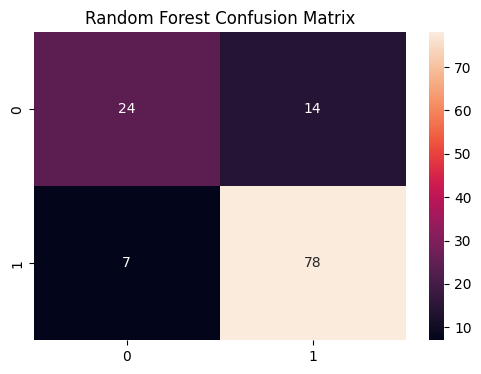

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.show()

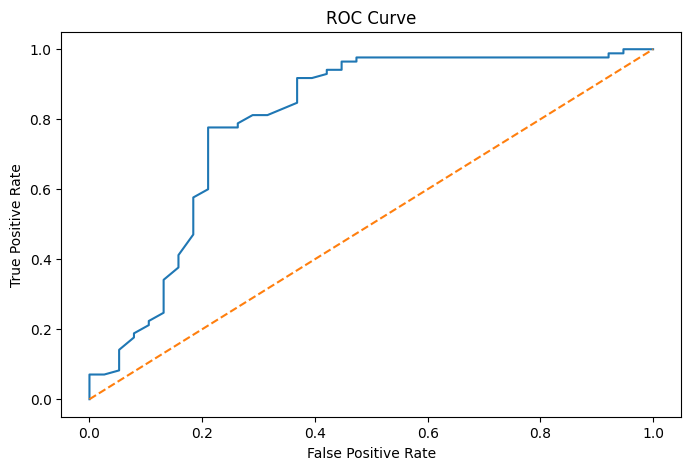

In [35]:
from sklearn.metrics import roc_curve

rf_probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [36]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

              Feature  Importance
10     Credit_History    0.208913
6     ApplicantIncome    0.157888
8          LoanAmount    0.145322
0             Loan_ID    0.145061
7   CoapplicantIncome    0.087227
11      Property_Area    0.076661
3          Dependents    0.054764
9    Loan_Amount_Term    0.039735
2             Married    0.027585
4           Education    0.024328


# Findings

1. Missing values were identified and handled using mode imputation.
2. Categorical variables were encoded using Label Encoding.
3. Feature scaling was performed using StandardScaler.
4. Class imbalance was addressed using SMOTE, resulting in a balanced training dataset.
5. Logistic Regression and Random Forest models were trained and evaluated.
6. Model performance was assessed using Precision, Recall, F1-Score, and ROC-AUC.
7. Random Forest generally captured non-linear relationships better than Logistic Regression.
8. Feature importance analysis identified the most influential factors affecting loan approval decisions.

# Model Comparison

## Logistic Regression
- Simple and interpretable model.
- Fast training time.
- Suitable for baseline predictions.

## Random Forest
- Captures complex relationships between variables.
- Generally achieves higher predictive performance.
- Provides feature importance for business insights.

## Evaluation Metrics
The models were compared using:
- Precision
- Recall
- F1 Score
- ROC-AUC

The model with the higher ROC-AUC and F1 Score is recommended for deployment.

# Business Interpretation

The analysis indicates that borrower characteristics such as income, credit history, loan amount, education level, and employment status influence loan approval decisions.

Feature importance analysis helps identify the factors that contribute most to approval outcomes. Financial institutions can use these insights to:
- Improve loan screening processes.
- Reduce default risk.
- Make faster approval decisions.
- Enhance customer experience through data-driven lending strategies.

# Suggested Threshold for Deployment

Although the default classification threshold is 0.50, organizations may adjust the threshold based on business requirements.

- Lower Threshold (e.g., 0.40):
  - Approves more applicants.
  - Higher recall.
  - Increased risk.

- Higher Threshold (e.g., 0.60):
  - More conservative approvals.
  - Lower risk.
  - Higher precision.

A threshold between 0.50 and 0.60 is recommended for balanced business performance.

# Conclusion

A complete machine learning pipeline was developed for loan approval prediction. The project included data preprocessing, missing value handling, categorical encoding, feature scaling, class imbalance treatment using SMOTE, model training, and evaluation. Logistic Regression and Random Forest models were compared using multiple performance metrics. The results demonstrate how machine learning can support efficient and data-driven loan approval decisions.